
![example](images/aircraft.jpg)


# RISK AVIATION PROJECT

**Authors:** Jose Ortega
***

## Overview

The task of this project is to analyse the data (aviation-accident-Database) in order to generate recommendatios for a business stakeholder.

## Business Problem

The company is looking in to new industries to diversify its portfolio, they want to purchase and operate airplanes for commercial and private enterprises, they do not know much about the potential risk of aircrafts. My task is to determine which aircrafts are the lowest risk for the company to start this new business endeavor.

## Data Understanding

The data used in this project is from the NTSB (National Transportation and Safety Board), that contains information from 1962 and later about civil aviation accidents and selected incidents within tha United States, its territories and possessions, and international waters.
Some of the important variables in the dataset are : Aircraft damage, category, make, model, number of engines, engine type, injury severity and total injuries.

In [1163]:
# Import standard packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [1164]:
df = pd.read_csv('./Data/AviationData.csv', encoding='latin1') # loading 'AviationData' as DataFrame

df.head() # to see how the data looks like

/var/folders/9f/w2s6x31n56v6ghk0qyt8tvx80000gn/T/ipykernel_35857/965402264.py:1: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Data/AviationData.csv', encoding='latin1') # loading 'AviationData' as DataFrame


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [1165]:
df.shape # to see how many columns and rows are in the DataFrame

(88889, 31)

In [1166]:
df.info() # to see the information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

We can see now that we are working with a large DataFrame , most of the columns have missing values , this is something that we need to consider.
We can also see that the columns names have dots between the words , we can replace the dots for underscore for easy reading.

In [1168]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [1169]:
df.columns = df.columns.str.replace('.','_') # replacing the dots in the columns for underscores

Now lets have a look of the data types in the DataFrame.

In [1171]:
df.dtypes


Event_Id                   object
Investigation_Type         object
Accident_Number            object
Event_Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport_Code               object
Airport_Name               object
Injury_Severity            object
Aircraft_damage            object
Aircraft_Category          object
Registration_Number        object
Make                       object
Model                      object
Amateur_Built              object
Number_of_Engines         float64
Engine_Type                object
FAR_Description            object
Schedule                   object
Purpose_of_flight          object
Air_carrier                object
Total_Fatal_Injuries      float64
Total_Serious_Injuries    float64
Total_Minor_Injuries      float64
Total_Uninjured           float64
Weather_Condition          object
Broad_phase_of_flight      object
Report_Status 

## Data Preparation

We can see that most of the columns have the right datatype (object,float) , the Event_Date has an object datatype instead of a datetime datatype, lets change this.

In [1174]:
df['Event_Date'] = pd.to_datetime(df['Event_Date']) #converting the datatype to datetime

In [1175]:
df['Event_Date'].head() # dtype now is datetime

0   1948-10-24
1   1962-07-19
2   1974-08-30
3   1977-06-19
4   1979-08-02
Name: Event_Date, dtype: datetime64[ns]

Now I would like to work with the year of the date (I dont really need month and day for the analysis).
To do that I will create another column called 'Event_Year' , in there we will display just the year. 

In [1177]:
df['Event_Year'] = df['Event_Date'].dt.year # creating the new column ['Eventy_Year'] with only year values
df['Event_Year'].head() # checking the result 


0    1948
1    1962
2    1974
3    1977
4    1979
Name: Event_Year, dtype: int32

Now it is time to drop the colummns we are not going to use for the analysis, there are quite a few columns that have more than 50% of missing values like Latitude, Longitud , Aircraft_Category, Far_Description , etc 
The columns that I going to use for analysis are :
Investigation_Type, Injury_Severity, Aircraft_damage, Aircraft_Category, Make, Model, Amateur_Built, Number_of_Engines, Engine_Type, Purpose_of_flight, Total_Fatal_Injuries, Total_Serious_Injuries, Total_Minor_Injuries, Total_Uninjured, Weather_Condition, Broad_phase_of_flight and the recently column I just created Event Year.

In [1179]:
# creating a list the columns we are going to use 

columns_to_use = ['Investigation_Type', 'Injury_Severity', 'Aircraft_damage', 'Aircraft_Category', 'Make', 'Model'
                  , 'Amateur_Built', 'Number_of_Engines', 'Engine_Type', 'Purpose_of_flight', 'Total_Fatal_Injuries'
                  , 'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured', 'Weather_Condition', 'Broad_phase_of_flight',
                  'Event_Year']

df_relevant_columns = df[columns_to_use]
df_relevant_columns
                  

,Investigation_Type,Injury_Severity,Aircraft_damage,Aircraft_Category,Make,Model,Amateur_Built,Number_of_Engines,Engine_Type,Purpose_of_flight,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Event_Year
0,Accident,Fatal(2),Destroyed,NaN,Stinson,108-3,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,UNK,Cruise,1948
1,Accident,Fatal(4),Destroyed,NaN,Piper,PA24-180,No,1.0,Reciprocating,Personal,4.0,0.0,0.0,0.0,UNK,Unknown,1962
2,Accident,Fatal(3),Destroyed,NaN,Cessna,172M,No,1.0,Reciprocating,Personal,3.0,NaN,NaN,NaN,IMC,Cruise,1974
3,Accident,Fatal(2),Destroyed,NaN,Rockwell,112,No,1.0,Reciprocating,Personal,2.0,0.0,0.0,0.0,IMC,Cruise,1977
4,Accident,Fatal(1),Destroyed,NaN,Cessna,501,No,NaN,NaN,Personal,1.0,2.0,NaN,0.0,VMC,Approach,1979
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,Accident,Minor,NaN,NaN,PIPER,PA-28-151,No,NaN,NaN,Personal,0.0,1.0,0.0,0.0,NaN,NaN,2022
88885,Accident,NaN,NaN,NaN,BELLANCA,7ECA,No,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,2022
88886,Accident,Non-Fatal,Substantial,Airplane,AMERICAN CHAMPION AIRCRAFT,8GCBC,No,1.0,NaN,Personal,0.0,0.0,0.0,1.0,VMC,NaN,2022
88887,Accident,NaN,NaN,NaN,CESSNA,210N,No,NaN,NaN,Personal,0.0,0.0,0.0,0.0,NaN,NaN,2022


In [1180]:
df_relevant_columns.info() # now we have only 17 columns 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Investigation_Type      88889 non-null  object 
 1   Injury_Severity         87889 non-null  object 
 2   Aircraft_damage         85695 non-null  object 
 3   Aircraft_Category       32287 non-null  object 
 4   Make                    88826 non-null  object 
 5   Model                   88797 non-null  object 
 6   Amateur_Built           88787 non-null  object 
 7   Number_of_Engines       82805 non-null  float64
 8   Engine_Type             81793 non-null  object 
 9   Purpose_of_flight       82697 non-null  object 
 10  Total_Fatal_Injuries    77488 non-null  float64
 11  Total_Serious_Injuries  76379 non-null  float64
 12  Total_Minor_Injuries    76956 non-null  float64
 13  Total_Uninjured         82977 non-null  float64
 14  Weather_Condition       84397 non-null

Let's have a look at the value count of "Aircraft_Category"

In [1182]:
df_relevant_columns['Aircraft_Category'].value_counts()

Aircraft_Category
Airplane             27617
Helicopter            3440
Glider                 508
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 14
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

We are only interested on Airplane "category" , so we need to keep only the rows with airplane as category

In [1184]:
df_relevant_columns = df_relevant_columns[df_relevant_columns['Aircraft_Category'] == 'Airplane']
df_relevant_columns.shape # now we can see we only have 27617 rows to work with

(27617, 17)

In [1185]:
# Let's have a look at the info 
df_relevant_columns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27617 entries, 5 to 88886
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Investigation_Type      27617 non-null  object 
 1   Injury_Severity         26803 non-null  object 
 2   Aircraft_damage         26335 non-null  object 
 3   Aircraft_Category       27617 non-null  object 
 4   Make                    27608 non-null  object 
 5   Model                   27586 non-null  object 
 6   Amateur_Built           27600 non-null  object 
 7   Number_of_Engines       24863 non-null  float64
 8   Engine_Type             23391 non-null  object 
 9   Purpose_of_flight       23878 non-null  object 
 10  Total_Fatal_Injuries    24452 non-null  float64
 11  Total_Serious_Injuries  24393 non-null  float64
 12  Total_Minor_Injuries    24739 non-null  float64
 13  Total_Uninjured         26717 non-null  float64
 14  Weather_Condition       24564 non-null  obj

In [1186]:
# Now let's have a look of the values in 'Amateur_Built'
df_relevant_columns['Amateur_Built'].value_counts()

Amateur_Built
No     24417
Yes     3183
Name: count, dtype: int64

Amateur Built are those planes constructed by individuals or organizations who are not engaged in professional aircraft construction.
For this reason we will drop those 3183 rows.

In [1188]:
df_relevant_columns = df_relevant_columns[df_relevant_columns['Amateur_Built'] == 'No']
df_relevant_columns.shape

(24417, 17)

In [1189]:
# Let's look at info now
df_relevant_columns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24417 entries, 5 to 88886
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Investigation_Type      24417 non-null  object 
 1   Injury_Severity         23604 non-null  object 
 2   Aircraft_damage         23147 non-null  object 
 3   Aircraft_Category       24417 non-null  object 
 4   Make                    24414 non-null  object 
 5   Model                   24399 non-null  object 
 6   Amateur_Built           24417 non-null  object 
 7   Number_of_Engines       21866 non-null  float64
 8   Engine_Type             20461 non-null  object 
 9   Purpose_of_flight       20734 non-null  object 
 10  Total_Fatal_Injuries    21651 non-null  float64
 11  Total_Serious_Injuries  21571 non-null  float64
 12  Total_Minor_Injuries    21855 non-null  float64
 13  Total_Uninjured         23699 non-null  float64
 14  Weather_Condition       21438 non-null  obj

In [1190]:
df_relevant_columns.isna().sum() # checking the actually quiantity of missing values

Investigation_Type            0
Injury_Severity             813
Aircraft_damage            1270
Aircraft_Category             0
Make                          3
Model                        18
Amateur_Built                 0
Number_of_Engines          2551
Engine_Type                3956
Purpose_of_flight          3683
Total_Fatal_Injuries       2766
Total_Serious_Injuries     2846
Total_Minor_Injuries       2562
Total_Uninjured             718
Weather_Condition          2979
Broad_phase_of_flight     18621
Event_Year                    0
dtype: int64

In [1191]:
# Let's check the porcentage of the missing values
(df_relevant_columns.isnull().mean() * 100).sort_values(ascending=False)

Broad_phase_of_flight     76.262440
Engine_Type               16.201827
Purpose_of_flight         15.083753
Weather_Condition         12.200516
Total_Serious_Injuries    11.655814
Total_Fatal_Injuries      11.328173
Total_Minor_Injuries      10.492690
Number_of_Engines         10.447639
Aircraft_damage            5.201294
Injury_Severity            3.329647
Total_Uninjured            2.940574
Model                      0.073719
Make                       0.012287
Investigation_Type         0.000000
Amateur_Built              0.000000
Aircraft_Category          0.000000
Event_Year                 0.000000
dtype: float64

In [1192]:
# 'Broad_phase_of_flight' has to many missing values , so I decided to drop that column
df_relevant_columns.drop(['Broad_phase_of_flight'], axis=1, inplace=True)
df_relevant_columns.drop(['Injury_Severity'], axis=1, inplace=True)
df_relevant_columns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24417 entries, 5 to 88886
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Investigation_Type      24417 non-null  object 
 1   Aircraft_damage         23147 non-null  object 
 2   Aircraft_Category       24417 non-null  object 
 3   Make                    24414 non-null  object 
 4   Model                   24399 non-null  object 
 5   Amateur_Built           24417 non-null  object 
 6   Number_of_Engines       21866 non-null  float64
 7   Engine_Type             20461 non-null  object 
 8   Purpose_of_flight       20734 non-null  object 
 9   Total_Fatal_Injuries    21651 non-null  float64
 10  Total_Serious_Injuries  21571 non-null  float64
 11  Total_Minor_Injuries    21855 non-null  float64
 12  Total_Uninjured         23699 non-null  float64
 13  Weather_Condition       21438 non-null  object 
 14  Event_Year              24417 non-null  int

In [1193]:
(df_relevant_columns.isnull().mean() * 100).sort_values(ascending=False)

Engine_Type               16.201827
Purpose_of_flight         15.083753
Weather_Condition         12.200516
Total_Serious_Injuries    11.655814
Total_Fatal_Injuries      11.328173
Total_Minor_Injuries      10.492690
Number_of_Engines         10.447639
Aircraft_damage            5.201294
Total_Uninjured            2.940574
Model                      0.073719
Make                       0.012287
Investigation_Type         0.000000
Aircraft_Category          0.000000
Amateur_Built              0.000000
Event_Year                 0.000000
dtype: float64

We also can see that columns 'Model' and 'Make' have very minimal missing values , for that reason we will drop this rows.

In [1195]:
df_relevant_columns.dropna(subset=['Model'], inplace=True)
df_relevant_columns.dropna(subset=['Make'], inplace=True)
df_relevant_columns.isna().sum()

Investigation_Type           0
Aircraft_damage           1267
Aircraft_Category            0
Make                         0
Model                        0
Amateur_Built                0
Number_of_Engines         2546
Engine_Type               3943
Purpose_of_flight         3674
Total_Fatal_Injuries      2760
Total_Serious_Injuries    2838
Total_Minor_Injuries      2555
Total_Uninjured            712
Weather_Condition         2970
Event_Year                   0
dtype: int64

In [1196]:
# Now let's check unique values for all the columns 
for index in df_relevant_columns:
    print(index,":", df_relevant_columns[index].unique())


Investigation_Type : ['Accident' 'Incident']
Aircraft_damage : ['Substantial' 'Destroyed' 'Minor' nan 'Unknown']
Aircraft_Category : ['Airplane']
Make : ['Mcdonnell Douglas' 'Cessna' 'Bellanca' ... 'PHANTOM' 'JAMES R DERNOVSEK'
 'ORLICAN S R O']
Model : ['DC9' '140' '401B' ... 'PHANTOM' 'KITFOX S5' 'M-8 EAGLE']
Amateur_Built : ['No']
Number_of_Engines : [ 2.  1.  3.  4. nan  0.  8.  6.]
Engine_Type : ['Turbo Fan' 'Reciprocating' 'Turbo Prop' 'Turbo Jet' nan 'Unknown'
 'Turbo Shaft' 'Electric' 'Geared Turbofan' 'UNK']
Purpose_of_flight : [nan 'Personal' 'Business' 'Instructional' 'Ferry' 'Unknown'
 'Executive/corporate' 'Aerial Observation' 'Aerial Application'
 'Public Aircraft' 'Skydiving' 'Positioning' 'Other Work Use'
 'Public Aircraft - Federal' 'Air Race/show' 'Flight Test'
 'Public Aircraft - State' 'Glider Tow' 'Banner Tow' 'Firefighting'
 'External Load' 'Air Race show' 'Public Aircraft - Local' 'Air Drop'
 'PUBS' 'ASHO']
Total_Fatal_Injuries : [ nan   0.   1.   2.   3.   8.   

Looking at the unique values of the dataset , we can fill the missing values with 0 and convert them to int data type for the columns:'Total_Fatal_Injuries', 'Total_Serious_Injuries', 'Total_Minor_Injuries' and 'Total_Uninjured'   

In [1198]:
# Filling missing values with 0 and converting to int
injury_columns = ['Total_Fatal_Injuries', 'Total_Serious_Injuries', 'Total_Minor_Injuries', 'Total_Uninjured']
df_relevant_columns[injury_columns] = df_relevant_columns[injury_columns].fillna(0).astype(int)

In [1199]:
df_relevant_columns.isna().sum()

Investigation_Type           0
Aircraft_damage           1267
Aircraft_Category            0
Make                         0
Model                        0
Amateur_Built                0
Number_of_Engines         2546
Engine_Type               3943
Purpose_of_flight         3674
Total_Fatal_Injuries         0
Total_Serious_Injuries       0
Total_Minor_Injuries         0
Total_Uninjured              0
Weather_Condition         2970
Event_Year                   0
dtype: int64

In [1200]:
# Let's have a look of the unique values of the other columns with missing values 
print(df_relevant_columns['Aircraft_damage'].unique())
print(df_relevant_columns['Number_of_Engines'].unique())
print(df_relevant_columns['Engine_Type'].unique())
print(df_relevant_columns['Purpose_of_flight'].unique())
print(df_relevant_columns['Weather_Condition'].unique())

['Substantial' 'Destroyed' 'Minor' nan 'Unknown']
[ 2.  1.  3.  4. nan  0.  8.  6.]
['Turbo Fan' 'Reciprocating' 'Turbo Prop' 'Turbo Jet' nan 'Unknown'
 'Turbo Shaft' 'Electric' 'Geared Turbofan' 'UNK']
[nan 'Personal' 'Business' 'Instructional' 'Ferry' 'Unknown'
 'Executive/corporate' 'Aerial Observation' 'Aerial Application'
 'Public Aircraft' 'Skydiving' 'Positioning' 'Other Work Use'
 'Public Aircraft - Federal' 'Air Race/show' 'Flight Test'
 'Public Aircraft - State' 'Glider Tow' 'Banner Tow' 'Firefighting'
 'External Load' 'Air Race show' 'Public Aircraft - Local' 'Air Drop'
 'PUBS' 'ASHO']
['VMC' 'IMC' 'UNK' nan 'Unk']


Now, time to deal with the missing values of the remaining columns 

In [1202]:
df_relevant_columns['Aircraft_damage'] = df_relevant_columns['Aircraft_damage'].fillna('Unknown') # filling nan values with 'Unknown'
df_relevant_columns['Engine_Type'] = df_relevant_columns['Engine_Type'].replace('UNK', 'Unknown') # replacing 'UNK' for 'Unknown'
df_relevant_columns['Engine_Type'] = df_relevant_columns['Engine_Type'].fillna('Unknown') # filling nan values with 'Unknown'
df_relevant_columns['Weather_Condition'] = df_relevant_columns['Weather_Condition'].replace('UNK', 'Unknown') # replacing 'UNK' for 'Unknown'
df_relevant_columns['Weather_Condition'] = df_relevant_columns['Weather_Condition'].replace('Unk', 'Unknown') # replacing 'Unk' for 'Unknown'
df_relevant_columns['Weather_Condition'] = df_relevant_columns['Weather_Condition'].fillna('Unknown') # filling nan values with 'Unknown'
df_relevant_columns['Purpose_of_flight'] = df_relevant_columns['Purpose_of_flight'].fillna('Unknown') # filling nan values with 'Unknown'


The last column to deal with missing values is 'Number_of_Engines', in this column we have some nan values and "0" engines, these are likely to be gliders, ultralights or experimental aircrafts , they do not align with commercial or private aviation needs, so I will drop these rows and fill the nan values with the mode.

In [1204]:
# finding the mode for the column 'Number_of_Engines'
df_relevant_columns['Number_of_Engines'].value_counts() 

Number_of_Engines
1.0    18210
2.0     3470
4.0      103
3.0       58
0.0        9
8.0        1
6.0        1
Name: count, dtype: int64

In [1205]:
# Now we know the mode for this column is 1.0 
df_relevant_columns['Number_of_Engines'] = df_relevant_columns['Number_of_Engines'].fillna(1.0).astype(int) # filling up the nan values with the mode
df_relevant_columns = df_relevant_columns[df_relevant_columns['Number_of_Engines'] != 0] # dropping rows with 0 values 


In [1206]:
# Now time to check the count of missing values 
df_relevant_columns.isna().sum()

Investigation_Type        0
Aircraft_damage           0
Aircraft_Category         0
Make                      0
Model                     0
Amateur_Built             0
Number_of_Engines         0
Engine_Type               0
Purpose_of_flight         0
Total_Fatal_Injuries      0
Total_Serious_Injuries    0
Total_Minor_Injuries      0
Total_Uninjured           0
Weather_Condition         0
Event_Year                0
dtype: int64

In [1207]:
# Now lets check how does it look the dataset after dealing with missing values
df_relevant_columns

,Investigation_Type,Aircraft_damage,Aircraft_Category,Make,Model,Amateur_Built,Number_of_Engines,Engine_Type,Purpose_of_flight,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Event_Year
5,Accident,Substantial,Airplane,Mcdonnell Douglas,DC9,No,2,Turbo Fan,Unknown,0,0,1,44,VMC,1979
7,Accident,Substantial,Airplane,Cessna,140,No,1,Reciprocating,Personal,0,0,0,2,VMC,1982
8,Accident,Substantial,Airplane,Cessna,401B,No,2,Reciprocating,Business,0,0,0,2,IMC,1982
12,Accident,Destroyed,Airplane,Bellanca,17-30A,No,1,Reciprocating,Personal,0,0,1,0,IMC,1982
13,Accident,Destroyed,Airplane,Cessna,R172K,No,1,Reciprocating,Personal,1,0,0,0,IMC,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88869,Accident,Substantial,Airplane,PIPER,PA42,No,2,Unknown,Unknown,0,0,0,1,Unknown,2022
88873,Accident,Substantial,Airplane,CIRRUS DESIGN CORP,SR22,No,1,Unknown,Personal,0,0,0,1,VMC,2022
88876,Accident,Substantial,Airplane,SWEARINGEN,SA226TC,No,2,Unknown,Unknown,0,0,0,1,Unknown,2022
88877,Accident,Substantial,Airplane,CESSNA,R172K,No,1,Unknown,Personal,0,1,0,0,VMC,2022


I noticed that in "Make" column we have for example Cessna and CESSNA , to fix this I will standardize to title case. 

In [1209]:
df_relevant_columns['Make'] = df_relevant_columns['Make'].str.title() 
df_relevant_columns

,Investigation_Type,Aircraft_damage,Aircraft_Category,Make,Model,Amateur_Built,Number_of_Engines,Engine_Type,Purpose_of_flight,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Event_Year
5,Accident,Substantial,Airplane,Mcdonnell Douglas,DC9,No,2,Turbo Fan,Unknown,0,0,1,44,VMC,1979
7,Accident,Substantial,Airplane,Cessna,140,No,1,Reciprocating,Personal,0,0,0,2,VMC,1982
8,Accident,Substantial,Airplane,Cessna,401B,No,2,Reciprocating,Business,0,0,0,2,IMC,1982
12,Accident,Destroyed,Airplane,Bellanca,17-30A,No,1,Reciprocating,Personal,0,0,1,0,IMC,1982
13,Accident,Destroyed,Airplane,Cessna,R172K,No,1,Reciprocating,Personal,1,0,0,0,IMC,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88869,Accident,Substantial,Airplane,Piper,PA42,No,2,Unknown,Unknown,0,0,0,1,Unknown,2022
88873,Accident,Substantial,Airplane,Cirrus Design Corp,SR22,No,1,Unknown,Personal,0,0,0,1,VMC,2022
88876,Accident,Substantial,Airplane,Swearingen,SA226TC,No,2,Unknown,Unknown,0,0,0,1,Unknown,2022
88877,Accident,Substantial,Airplane,Cessna,R172K,No,1,Unknown,Personal,0,1,0,0,VMC,2022


In [1210]:
df_relevant_columns.reset_index(drop=True, inplace=True) #reseting index

In [1288]:
df_relevant_columns.to_csv("Clean_Aviation_Project.csv", index=False)
# df_relevant_columns.info()
# df_relevant_columns.isna().sum()
#need to drop 'Broad_phase_of_flight'
#make all capitals for Model and Make
# next step amateur_built , and lets keep cleaning the data
# df_relevant_columns['Make'].value_counts()
# df_relevant_columns['Aircraft_damage'].value_counts()
# df_relevant_columns.duplicated().sum()
# print(df_relevant_columns['Make'].unique())


['Mcdonnell Douglas' 'Cessna' 'Bellanca' ... 'Phantom' 'James R Dernovsek'
 'Orlican S R O']


## Data Modeling

After cleaning and filtering the data , we are going perform the analysis by creating a few visualizations , the following visualizations are going to be done using pandas but the visualizations we are going to use for the recommendatios are going be done in Tableau , the link for the dashboard in tableau, you can find the link in here: 


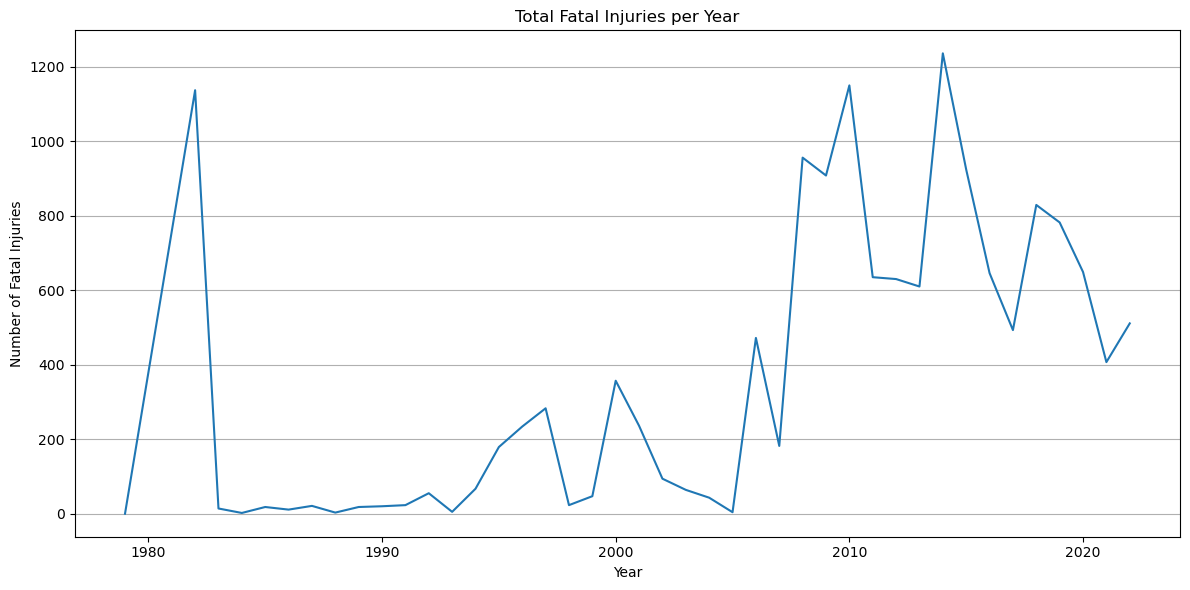

In [1280]:
# Plotting a line graph of fatal injuries per year

fatalities_per_year = df_relevant_columns.groupby('Event_Year')['Total_Fatal_Injuries'].sum()

# Plotting
plt.figure(figsize=(12, 6))
fatalities_per_year.plot(kind='line')
plt.title('Total Fatal Injuries per Year')
plt.xlabel('Year')
plt.ylabel('Number of Fatal Injuries')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

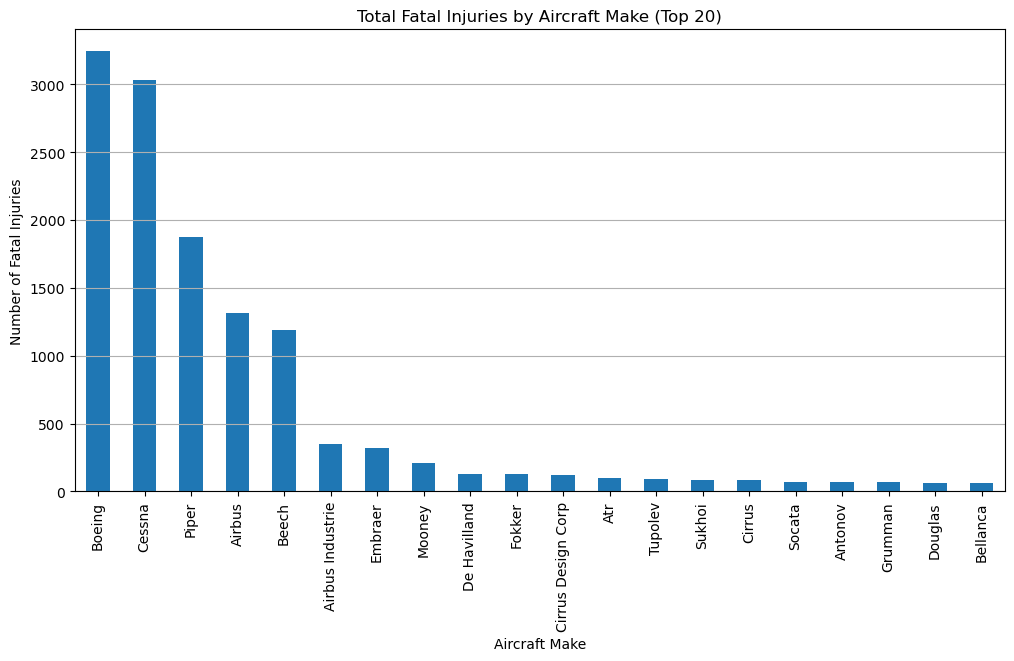

In [1266]:
# Plotting a bar graph of fatal injuries by aircraft make

# Group data by aircraft Make and sum fatal injuries
fatalities_by_make = df_relevant_columns.groupby('Make')['Total_Fatal_Injuries'].sum().sort_values(ascending=False).head(20)

# Plotting
plt.figure(figsize=(12, 6))
fatalities_by_make.plot(kind='bar')
plt.title('Total Fatal Injuries by Aircraft Make (Top 20)')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Fatal Injuries')
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
plt.grid(axis='y')
plt.show()


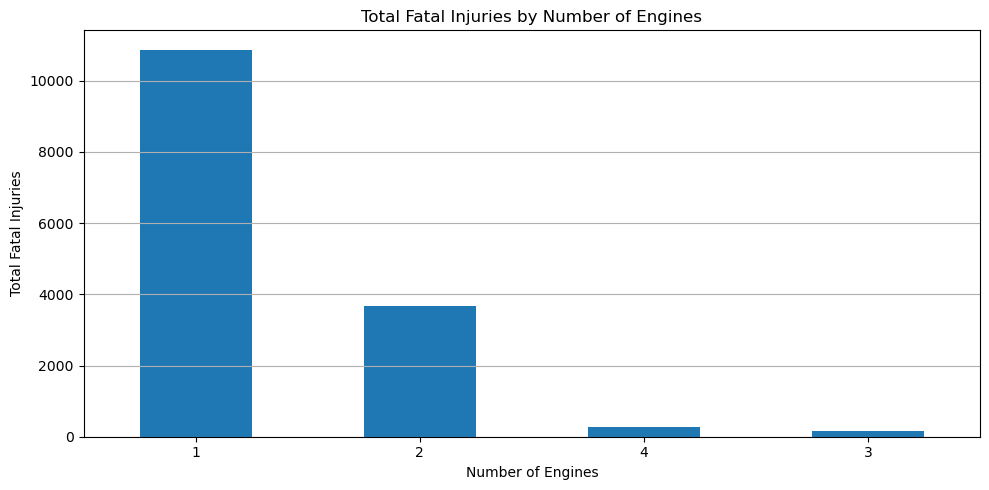

In [1284]:
# Plotting a bar graph of fatal injuries by number of Engines

# Filter for rows with at least one fatal injury
fatal_accidents = df_relevant_columns[df_relevant_columns['Total_Fatal_Injuries'] > 0]

# Group by 'Number_of_Engines' and sum fatalities
fatalities_by_engine_count = fatal_accidents.groupby('Number_of_Engines')['Total_Fatal_Injuries'].sum().sort_values(ascending=False)



plt.figure(figsize=(10, 5))
fatalities_by_engine_count.plot(kind='bar')
plt.title('Total Fatal Injuries by Number of Engines')
plt.xlabel('Number of Engines')
plt.ylabel('Total Fatal Injuries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()




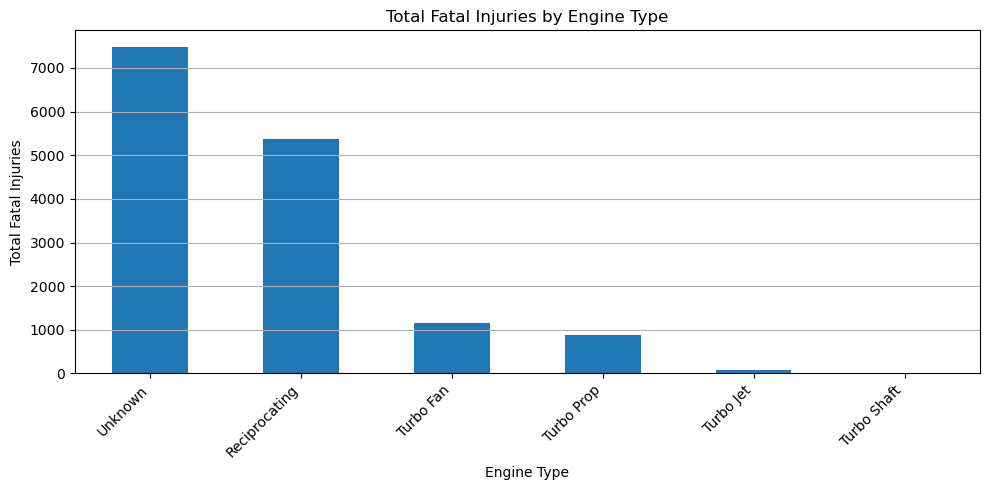

In [1274]:
# Filter for rows with at least one fatal injury
fatal_accidents2 = df_relevant_columns[df_relevant_columns['Total_Fatal_Injuries'] > 0]

# Group by 'Engine_Type' and sum fatalities
fatalities_by_engine_type = fatal_accidents2.groupby('Engine_Type')['Total_Fatal_Injuries'].sum().sort_values(ascending=False)



plt.figure(figsize=(10, 5))
fatalities_by_engine_type.plot(kind='bar')
plt.title('Total Fatal Injuries by Engine Type')
plt.xlabel('Engine Type')
plt.ylabel('Total Fatal Injuries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

## Evaluation

The aim for the 3 visualizations that I created using Tableau is to recommend aircraft types and models based on safety data , to do this I am using fatalaty rates by engine configuration, engine type and aircraft model.


Some of the key findings are :

* 2 and 4 engines offer better redundancy and safety
* 1 engine: lower crash severity but highest fatalities
* 3 engines: higher fatality rate per crash
* Reciprocating Engine: Lowest fatality rate
* Turbofan engine: Suitable for commercial operations
* Piper PA-18-150 and Cessna 180: Lowest fatality rates
* Cessna 172 variants: Moderate to low fatality rates-safe and reliable


## Conclusions
Following the analysis, these are the 3 recommendations for the company to consider:


1.  Choose 2 or 4 engines aircraft for balanced safety and performance.
1.  Use reciprocating engines for general aviation; turbofans for commercial and avoid turbojets.
1.  Prioritize aircraft models with lowest fatality rates:
    * Piper PA-18-150
    * Cessna 180
    * Cessna 172 variants

Project Limitations: For better analysis, it would be useful to have the data of flight hours or number of flights, another limitation that I have found it that the "purpose of flight" some of the variables can referto  either private or commercial use , so I think It would be good to have some clarification in exactly what are the use of the aircraft to be purchased.